In [1]:
import pandas as pd
from pathlib import Path

expression_path = Path(
    "../data/raw/gbm_tcga_pan_can_atlas_2018_mrna_rsem.txt"
)

print("Exists:", expression_path.exists())

Exists: True


In [2]:
expression = pd.read_csv(
    expression_path,
    sep="\t",
    low_memory=False
)

print("Rows:", expression.shape[0])
print("Columns:", expression.shape[1])

Rows: 20531
Columns: 162


In [3]:
expression.columns.tolist()[:20]

['Hugo_Symbol',
 'Entrez_Gene_Id',
 'TCGA-02-0047-01',
 'TCGA-02-0055-01',
 'TCGA-02-2483-01',
 'TCGA-02-2485-01',
 'TCGA-02-2486-01',
 'TCGA-06-0125-01',
 'TCGA-06-0125-02',
 'TCGA-06-0129-01',
 'TCGA-06-0130-01',
 'TCGA-06-0132-01',
 'TCGA-06-0138-01',
 'TCGA-06-0141-01',
 'TCGA-06-0157-01',
 'TCGA-06-0158-01',
 'TCGA-06-0168-01',
 'TCGA-06-0171-02',
 'TCGA-06-0174-01',
 'TCGA-06-0178-01']

In [4]:
expression.head()

,Hugo_Symbol,Entrez_Gene_Id,TCGA-02-0047-01,TCGA-02-0055-01,TCGA-02-2483-01,TCGA-02-2485-01,TCGA-02-2486-01,TCGA-06-0125-01,TCGA-06-0125-02,TCGA-06-0129-01,...,TCGA-41-3915-01,TCGA-41-4097-01,TCGA-41-5651-01,TCGA-76-4925-01,TCGA-76-4926-01,TCGA-76-4927-01,TCGA-76-4928-01,TCGA-76-4929-01,TCGA-76-4931-01,TCGA-76-4932-01
0,NaN,100130426,0.0000,0.0000,0.0000,0.0000,0.0000,0.4604,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1,NaN,100133144,3.0732,0.0000,2.9467,15.9952,5.5610,9.9246,3.3758,22.3207,...,8.2279,15.2648,1.2190,12.2160,9.5716,2.4096,10.1709,8.4757,6.1600,0.0000
2,UBE2Q2P2,100134869,6.7611,15.6973,13.9398,14.9571,4.8049,11.6684,3.3862,16.8239,...,10.2174,13.8987,10.3611,17.3596,13.9689,6.4257,6.4812,3.2496,7.9576,9.9502
3,HMGB1P1,10357,54.7036,31.3945,60.3441,91.8238,62.5366,52.1491,41.6125,76.2289,...,35.5731,27.6285,70.0838,108.1350,70.5556,43.0201,42.4584,62.2278,58.8188,60.1990
4,NaN,10431,886.3210,885.7740,1234.8300,470.0000,546.3410,391.9330,419.2460,642.3830,...,512.5160,593.2460,507.6950,531.9330,588.0410,620.8840,533.7420,668.9000,458.3530,499.5020


In [5]:
expression.iloc[:, :8].head(10)

,Hugo_Symbol,Entrez_Gene_Id,TCGA-02-0047-01,TCGA-02-0055-01,TCGA-02-2483-01,TCGA-02-2485-01,TCGA-02-2486-01,TCGA-06-0125-01
0,NaN,100130426,0.0000,0.0000,0.0000,0.0000,0.0000,0.4604
1,NaN,100133144,3.0732,0.0000,2.9467,15.9952,5.5610,9.9246
2,UBE2Q2P2,100134869,6.7611,15.6973,13.9398,14.9571,4.8049,11.6684
3,HMGB1P1,10357,54.7036,31.3945,60.3441,91.8238,62.5366,52.1491
4,NaN,10431,886.3210,885.7740,1234.8300,470.0000,546.3410,391.9330
5,NaN,136542,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
6,NaN,155060,232.9510,162.0180,135.0920,417.6190,276.2190,748.4210
7,RNU12-2P,26823,0.0000,0.5606,0.0000,1.9048,0.0000,1.6297
8,SSX9P,280660,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
9,NaN,317712,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


In [6]:
expression_sample_ids = set(expression.columns[2:])

print("Expression samples:", len(expression_sample_ids))

Expression samples: 160


In [7]:
clinical_path = Path("../data/processed/gbm_primary_clinical.tsv")

primary_clinical = pd.read_csv(
    clinical_path,
    sep="\t"
)

primary_sample_ids = set(primary_clinical["Sample ID"])

expression_primary_ids = (
    expression_sample_ids & primary_sample_ids
)

expression_not_primary = (
    expression_sample_ids - primary_sample_ids
)

print("Expression primary samples:",
      len(expression_primary_ids))

print("Expression samples not in primary cohort:",
      len(expression_not_primary))

expression_not_primary

Expression primary samples: 153
Expression samples not in primary cohort: 7


{'TCGA-06-0125-02',
 'TCGA-06-0171-02',
 'TCGA-06-0190-02',
 'TCGA-06-0210-02',
 'TCGA-06-0211-02',
 'TCGA-06-0221-02',
 'TCGA-14-1034-02'}

In [8]:
sequenced_path = Path(
    "../data/raw/gbm_tcga_pan_can_atlas_2018_cases_sequenced.txt"
)

lines = sequenced_path.read_text().splitlines()

case_ids_line = next(
    line for line in lines
    if line.startswith("case_list_ids:")
)

sequenced_sample_ids = set(
    case_ids_line.split(":", 1)[1].strip().split("\t")
)

sequenced_primary_ids = (
    sequenced_sample_ids & primary_sample_ids
)

print("Mutation-profiled primary samples:",
      len(sequenced_primary_ids))

Mutation-profiled primary samples: 390


In [9]:
# calculate the overlap
multiomics_primary_ids = (
    expression_primary_ids & sequenced_primary_ids
)

print(
    "Primary samples with BOTH expression and mutation profiling:",
    len(multiomics_primary_ids)
)

Primary samples with BOTH expression and mutation profiling: 152


In [10]:
# check which expression-primary samples are missing mutation profiling
expression_without_mutation_profile = (
    expression_primary_ids - sequenced_primary_ids
)

print(
    "Primary expression samples without mutation profiling:",
    len(expression_without_mutation_profile)
)

expression_without_mutation_profile

Primary expression samples without mutation profiling: 1


{'TCGA-15-1444-01'}

In [11]:
multiomics_primary_ids = sorted(multiomics_primary_ids)

print("Multi-omics samples:", len(multiomics_primary_ids))
print(multiomics_primary_ids[:10])

Multi-omics samples: 152
['TCGA-02-0047-01', 'TCGA-02-0055-01', 'TCGA-02-2483-01', 'TCGA-02-2485-01', 'TCGA-02-2486-01', 'TCGA-06-0125-01', 'TCGA-06-0129-01', 'TCGA-06-0130-01', 'TCGA-06-0132-01', 'TCGA-06-0138-01']


In [12]:
expression_multiomics = expression[
    ["Hugo_Symbol", "Entrez_Gene_Id"] + multiomics_primary_ids
].copy()

print("Rows (genes):", expression_multiomics.shape[0])
print("Columns total:", expression_multiomics.shape[1])
print(
    "Expression sample columns:",
    expression_multiomics.shape[1] - 2
)

Rows (genes): 20531
Columns total: 154
Expression sample columns: 152


In [13]:
recurrent_expression_columns = [
    col for col in expression_multiomics.columns
    if col.startswith("TCGA-") and col.endswith("-02")
]

print("Recurrent samples remaining:",
      len(recurrent_expression_columns))

recurrent_expression_columns

expression_multiomics.iloc[:, :8].head()

Recurrent samples remaining: 0


,Hugo_Symbol,Entrez_Gene_Id,TCGA-02-0047-01,TCGA-02-0055-01,TCGA-02-2483-01,TCGA-02-2485-01,TCGA-02-2486-01,TCGA-06-0125-01
0,NaN,100130426,0.0000,0.0000,0.0000,0.0000,0.0000,0.4604
1,NaN,100133144,3.0732,0.0000,2.9467,15.9952,5.5610,9.9246
2,UBE2Q2P2,100134869,6.7611,15.6973,13.9398,14.9571,4.8049,11.6684
3,HMGB1P1,10357,54.7036,31.3945,60.3441,91.8238,62.5366,52.1491
4,NaN,10431,886.3210,885.7740,1234.8300,470.0000,546.3410,391.9330


In [14]:
# Count missing gene symbols
missing_symbols = expression_multiomics["Hugo_Symbol"].isna().sum()

print("Rows with missing Hugo_Symbol:", missing_symbols)

# Check duplicate Hugo gene symbols
non_missing_symbols = expression_multiomics[
    "Hugo_Symbol"
].dropna()

print(
    "Unique non-missing Hugo symbols:",
    non_missing_symbols.nunique()
)

print(
    "Duplicated Hugo symbol rows:",
    non_missing_symbols.duplicated().sum()
)

# Check Entrez gene IDs
print(
    "Missing Entrez Gene IDs:",
    expression_multiomics["Entrez_Gene_Id"].isna().sum()
)

print(
    "Unique Entrez Gene IDs:",
    expression_multiomics["Entrez_Gene_Id"].nunique()
)

print(
    "Duplicated Entrez Gene ID rows:",
    expression_multiomics["Entrez_Gene_Id"].duplicated().sum()
)

# Check missing expression values
expression_values = expression_multiomics[
    multiomics_primary_ids
]
print(
    "Total missing expression values:",
    expression_values.isna().sum().sum()
)
print(
    "Genes containing at least one missing value:",
    expression_values.isna().any(axis=1).sum()
)

print(
    "Samples containing at least one missing value:",
    expression_values.isna().any(axis=0).sum()
)

Rows with missing Hugo_Symbol: 13


Unique non-missing Hugo symbols: 20511
Duplicated Hugo symbol rows: 7
Missing Entrez Gene IDs: 0
Unique Entrez Gene IDs: 20505
Duplicated Entrez Gene ID rows: 26
Total missing expression values: 0
Genes containing at least one missing value: 0
Samples containing at least one missing value: 0


In [15]:
missing_symbol_rows = expression_multiomics[
    expression_multiomics["Hugo_Symbol"].isna()
]

missing_symbol_rows[
    ["Hugo_Symbol", "Entrez_Gene_Id"]
]

duplicated_symbols = expression_multiomics[
    expression_multiomics["Hugo_Symbol"].notna()
    & expression_multiomics["Hugo_Symbol"].duplicated(keep=False)
].sort_values("Hugo_Symbol")

duplicated_symbols[
    ["Hugo_Symbol", "Entrez_Gene_Id"]
]

duplicated_entrez = expression_multiomics[
    expression_multiomics["Entrez_Gene_Id"].duplicated(keep=False)
].sort_values("Entrez_Gene_Id")

duplicated_entrez[
    ["Hugo_Symbol", "Entrez_Gene_Id"]
]

print("Rows with missing symbols:", len(missing_symbol_rows))
print("Rows involved in duplicated Hugo symbols:", len(duplicated_symbols))
print("Rows involved in duplicated Entrez IDs:", len(duplicated_entrez))

Rows with missing symbols: 13
Rows involved in duplicated Hugo symbols: 14
Rows involved in duplicated Entrez IDs: 50


In [16]:
missing_symbol_rows[
    ["Hugo_Symbol", "Entrez_Gene_Id"]
].to_string(index=False)

duplicated_symbols[
    ["Hugo_Symbol", "Entrez_Gene_Id"]
].to_string(index=False)

duplicated_entrez[
    ["Hugo_Symbol", "Entrez_Gene_Id"]
].to_string(index=False)

'Hugo_Symbol  Entrez_Gene_Id\n    C9orf47            1903\n      S1PR3            1903\n      FGF13            2258\n      FGF13            2258\n NCRNA00201            3192\n     HNRNPU            3192\n     CTAGE5            4253\n       MIA2            4253\n      SEPT4            5414\n   C17orf47            5414\n  C10orf113           10529\n       NEBL           10529\n  LOC283174           22997\n     IGSF9B           22997\n      MACF1           23499\n   KIAA0754           23499\n      DGCR9           26220\n     DGCR10           26220\n      DGCR5           26220\n     TMEM8B           51754\n     TMEM8B           51754\n     ELMOD1           55531\n     ELMOD1           55531\n      EHMT1           79813\n   FLJ40292           79813\n       LCOR           84458\n   C10orf12           84458\n     CXorf1           84631\n    SLITRK2           84631\n     SNAP47          116841\n     SNAP47          116841\n   ARHGAP42          143872\n    TMEM133          143872\n  C14orf139  

In [17]:
missing_symbol_rows[
    ["Hugo_Symbol", "Entrez_Gene_Id"]
].to_string(index=False)

duplicated_symbols[
    ["Hugo_Symbol", "Entrez_Gene_Id"]
].to_string(index=False)

'Hugo_Symbol  Entrez_Gene_Id\n     ELMOD1           55531\n     ELMOD1           55531\n      FGF13            2258\n      FGF13            2258\n     NKAIN3          286183\n     NKAIN3          286183\n PALM2AKAP2          445815\n PALM2AKAP2          445815\n      QSOX1          200058\n      QSOX1            5768\n     SNAP47          116841\n     SNAP47          116841\n     TMEM8B           51754\n     TMEM8B           51754'

In [18]:
missing_symbol_rows[
    ["Hugo_Symbol", "Entrez_Gene_Id"]
].to_string(index=False)

'Hugo_Symbol  Entrez_Gene_Id\n        NaN       100130426\n        NaN       100133144\n        NaN           10431\n        NaN          136542\n        NaN          155060\n        NaN          317712\n        NaN          391343\n        NaN          553137\n        NaN           57714\n        NaN          645851\n        NaN          652919\n        NaN          728603\n        NaN          729884'

In [19]:
duplicate_symbol_summary = []

for symbol, group in expression_multiomics[
    expression_multiomics["Hugo_Symbol"].notna()
].groupby("Hugo_Symbol"):

    if len(group) > 1:
        values = group[multiomics_primary_ids]

        all_expression_identical = (
            values.nunique(axis=0, dropna=False) <= 1
        ).all()

        duplicate_symbol_summary.append({
            "Hugo_Symbol": symbol,
            "Rows": len(group),
            "Entrez_IDs": group["Entrez_Gene_Id"].tolist(),
            "Expression_identical": all_expression_identical
        })

duplicate_symbol_summary = pd.DataFrame(
    duplicate_symbol_summary
)

duplicate_symbol_summary

,Hugo_Symbol,Rows,Entrez_IDs,Expression_identical
0,ELMOD1,2,"[55531, 55531]",False
1,FGF13,2,"[2258, 2258]",False
2,NKAIN3,2,"[286183, 286183]",False
3,PALM2AKAP2,2,"[445815, 445815]",False
4,QSOX1,2,"[200058, 5768]",False
5,SNAP47,2,"[116841, 116841]",False
6,TMEM8B,2,"[51754, 51754]",False


In [20]:
duplicate_entrez_summary = []

for entrez_id, group in expression_multiomics.groupby(
    "Entrez_Gene_Id"
):

    if len(group) > 1:
        values = group[multiomics_primary_ids]

        all_expression_identical = (
            values.nunique(axis=0, dropna=False) <= 1
        ).all()

        duplicate_entrez_summary.append({
            "Entrez_Gene_Id": entrez_id,
            "Rows": len(group),
            "Hugo_Symbols": group["Hugo_Symbol"].tolist(),
            "Expression_identical": all_expression_identical
        })

duplicate_entrez_summary = pd.DataFrame(
    duplicate_entrez_summary
)

duplicate_entrez_summary

,Entrez_Gene_Id,Rows,Hugo_Symbols,Expression_identical
0,1903,2,"[C9orf47, S1PR3]",False
1,2258,2,"[FGF13, FGF13]",False
2,3192,2,"[HNRNPU, NCRNA00201]",False
3,4253,2,"[CTAGE5, MIA2]",False
4,5414,2,"[C17orf47, SEPT4]",False
5,10529,2,"[C10orf113, NEBL]",False
6,22997,2,"[IGSF9B, LOC283174]",False
7,23499,2,"[KIAA0754, MACF1]",False
8,26220,3,"[DGCR10, DGCR5, DGCR9]",False
9,51754,2,"[TMEM8B, TMEM8B]",False


In [21]:
print(
    "Duplicate Hugo groups:",
    len(duplicate_symbol_summary)
)

print(
    "Hugo groups with identical expression:",
    duplicate_symbol_summary["Expression_identical"].sum()
)

print(
    "Duplicate Entrez groups:",
    len(duplicate_entrez_summary)
)

print(
    "Entrez groups with identical expression:",
    duplicate_entrez_summary["Expression_identical"].sum()
)

Duplicate Hugo groups: 7
Hugo groups with identical expression: 0
Duplicate Entrez groups: 24
Entrez groups with identical expression: 0


In [22]:
expression_with_symbols = expression_multiomics[
    expression_multiomics["Hugo_Symbol"].notna()
].copy()

print(
    "Rows before:",
    expression_multiomics.shape[0]
)

print(
    "Rows after removing missing Hugo symbols:",
    expression_with_symbols.shape[0]
)

Rows before: 20531
Rows after removing missing Hugo symbols: 20518


In [23]:
expression_gene_matrix = (
    expression_with_symbols
    .groupby("Hugo_Symbol")[multiomics_primary_ids]
    .median()
)

print(
    "Unique genes after collapsing duplicates:",
    expression_gene_matrix.shape[0]
)

print(
    "Samples:",
    expression_gene_matrix.shape[1]
)

Unique genes after collapsing duplicates: 20511
Samples: 152


In [24]:
print(
    "Duplicated gene symbols remaining:",
    expression_gene_matrix.index.duplicated().sum()
)

print("Matrix shape:", expression_gene_matrix.shape)

Duplicated gene symbols remaining: 0
Matrix shape: (20511, 152)


In [25]:
genes_to_check = [
    "TP53",
    "EGFR",
    "PTEN",
    "PIK3CA"
]

expression_gene_matrix.loc[
    expression_gene_matrix.index.intersection(genes_to_check)
].iloc[:, :6]

,TCGA-02-0047-01,TCGA-02-0055-01,TCGA-02-2483-01,TCGA-02-2485-01,TCGA-02-2486-01,TCGA-06-0125-01
Hugo_Symbol,,,,,,
EGFR,564.24,264.050,190.814,27073.100,6124.960,29987.200
PIK3CA,522.45,627.330,417.098,332.857,251.829,372.785
PTEN,1955.19,1633.080,1303.220,895.714,970.122,589.122
TP53,1834.72,993.413,3854.780,2690.950,1153.050,2312.890


In [26]:
import numpy as np

expression_values_flat = expression_gene_matrix.to_numpy().ravel()

print("Total expression values:", len(expression_values_flat))
print("Minimum:", expression_values_flat.min())
print("Maximum:", expression_values_flat.max())
print("Mean:", expression_values_flat.mean())
print("Median:", np.median(expression_values_flat))

print("25th percentile:", np.percentile(expression_values_flat, 25))
print("75th percentile:", np.percentile(expression_values_flat, 75))
print("90th percentile:", np.percentile(expression_values_flat, 90))
print("95th percentile:", np.percentile(expression_values_flat, 95))
print("99th percentile:", np.percentile(expression_values_flat, 99))

Total expression values: 3117672
Minimum: 0.0
Maximum: 1026360.0
Mean: 925.750003737773
Median: 221.664


25th percentile: 6.4777
75th percentile: 838.374
90th percentile: 1992.56


95th percentile: 3312.564499999997


99th percentile: 9842.907600000017


In [27]:
zero_count = (expression_values_flat == 0).sum()
negative_count = (expression_values_flat < 0).sum()

print("Zero values:", zero_count)
print(
    "Percentage zeros:",
    round(zero_count / len(expression_values_flat) * 100, 2),
    "%"
)

print("Negative values:", negative_count)

Zero values: 447625
Percentage zeros: 14.36 %
Negative values: 0


In [28]:
zero_fraction_per_gene = (
    expression_gene_matrix == 0
).mean(axis=1)

print(
    "Genes zero in every patient:",
    (zero_fraction_per_gene == 1).sum()
)

print(
    "Genes zero in at least 90% of patients:",
    (zero_fraction_per_gene >= 0.90).sum()
)

print(
    "Genes zero in at least 50% of patients:",
    (zero_fraction_per_gene >= 0.50).sum()
)

Genes zero in every patient: 546
Genes zero in at least 90% of patients: 1585
Genes zero in at least 50% of patients: 2885


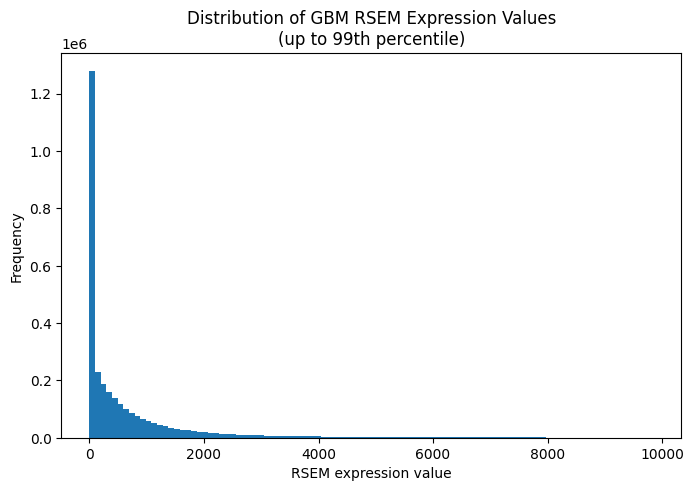

In [29]:
import matplotlib.pyplot as plt

upper_limit = np.percentile(
    expression_values_flat,
    99
)

plt.figure(figsize=(8, 5))

plt.hist(
    expression_values_flat[
        expression_values_flat <= upper_limit
    ],
    bins=100
)

plt.xlabel("RSEM expression value")
plt.ylabel("Frequency")
plt.title("Distribution of GBM RSEM Expression Values\n(up to 99th percentile)")

plt.show()

In [30]:
expression_log2 = np.log2(
    expression_gene_matrix + 1
)

print("Original shape:",
      expression_gene_matrix.shape)

print("Log2 shape:",
      expression_log2.shape)

Original shape: (20511, 152)
Log2 shape: (20511, 152)


In [31]:
log_values_flat = expression_log2.to_numpy().ravel()

print("Minimum log2 value:",
      log_values_flat.min())

print("Maximum log2 value:",
      log_values_flat.max())

print("NaN values:",
      np.isnan(log_values_flat).sum())

print("Infinite values:",
      np.isinf(log_values_flat).sum())

Minimum log2 value: 0.0
Maximum log2 value: 19.969106825909254
NaN values: 0
Infinite values: 0


In [32]:
print("RAW")
print("Mean:", expression_values_flat.mean())
print("Median:", np.median(expression_values_flat))
print("99th percentile:",
      np.percentile(expression_values_flat, 99))
print("Maximum:",
      expression_values_flat.max())

print("\nLOG2(x + 1)")
print("Mean:", log_values_flat.mean())
print("Median:", np.median(log_values_flat))
print("99th percentile:",
      np.percentile(log_values_flat, 99))
print("Maximum:",
      log_values_flat.max())

RAW
Mean: 925.750003737773
Median: 221.664
99th percentile: 9842.907600000017
Maximum: 1026360.0

LOG2(x + 1)
Mean: 6.552118766530938
Median: 7.7987245138645145


99th percentile:

 13.26501540034434
Maximum: 19.969106825909254


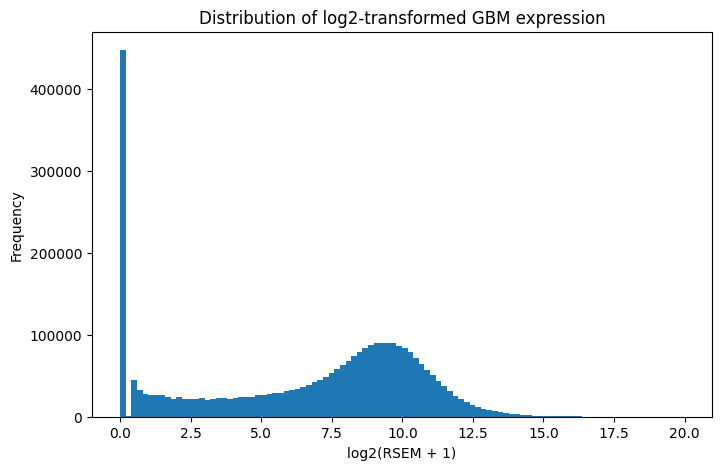

In [33]:
plt.figure(figsize=(8, 5))

plt.hist(
    log_values_flat,
    bins=100
)

plt.xlabel("log2(RSEM + 1)")
plt.ylabel("Frequency")
plt.title(
    "Distribution of log2-transformed GBM expression"
)

plt.show()

In [34]:
expression_log2.loc[
    ["EGFR", "PIK3CA", "PTEN", "TP53"]
].iloc[:, :6]

,TCGA-02-0047-01,TCGA-02-0055-01,TCGA-02-2483-01,TCGA-02-2485-01,TCGA-02-2486-01,TCGA-06-0125-01
Hugo_Symbol,,,,,,
EGFR,9.142720,8.050121,7.583564,14.724626,12.580720,14.872107
PIK3CA,9.031908,9.295379,8.707697,8.383086,7.982018,8.546065
PTEN,10.933831,10.674263,10.348972,9.808504,9.923509,9.204869
TP53,10.842130,9.957701,11.912807,11.394436,10.172490,11.176105


In [35]:
unique_values_per_gene = expression_log2.nunique(axis=1)

constant_genes = unique_values_per_gene[
    unique_values_per_gene == 1
].index

print("Genes with exactly one value across all patients:",
      len(constant_genes))

all_zero_genes = expression_log2.index[
    (expression_log2 == 0).all(axis=1)
]

print("Genes zero in all patients:",
      len(all_zero_genes))

Genes with exactly one value across all patients: 546
Genes zero in all patients: 546


In [36]:
constant_nonzero_genes = set(constant_genes) - set(all_zero_genes)

print(
    "Constant non-zero genes:",
    len(constant_nonzero_genes)
)

list(constant_nonzero_genes)[:20]

Constant non-zero genes: 0


[]

In [37]:
expression_log2_filtered = expression_log2.drop(
    index=constant_genes
)

print("Before filtering:",
      expression_log2.shape)

print("After filtering:",
      expression_log2_filtered.shape)

Before filtering: (20511, 152)
After filtering: (19965, 152)


In [38]:
for gene in ["EGFR", "TP53", "PTEN", "PIK3CA"]:
    print(
        gene,
        gene in expression_log2_filtered.index
    )

EGFR True
TP53 True
PTEN True
PIK3CA True


In [39]:
gene_median = expression_log2_filtered.median(axis=1)

gene_mad = (
    expression_log2_filtered
    .sub(gene_median, axis=0)
    .abs()
    .median(axis=1)
)

print("Genes:", len(gene_median))
print(
    "Genes with MAD = 0:",
    (gene_mad == 0).sum()
)
print(
    "Genes with MAD > 0:",
    (gene_mad > 0).sum()
)

Genes: 19965
Genes with MAD = 0: 2326
Genes with MAD > 0: 17639


In [40]:
baseline_check = pd.DataFrame({
    "Median_log2_expression": gene_median,
    "MAD": gene_mad
})

baseline_check.loc[
    ["EGFR", "TP53", "PTEN", "PIK3CA"]
]

,Median_log2_expression,MAD
Hugo_Symbol,,
EGFR,12.029452,2.094817
TP53,10.724358,0.354489
PTEN,9.933077,0.333721
PIK3CA,8.380782,0.350070


In [41]:
zero_mad_genes = gene_mad[
    gene_mad == 0
].index

print("Number of zero-MAD genes:", len(zero_mad_genes))

list(zero_mad_genes[:20])

Number of zero-MAD genes: 2326


['A1CF',
 'AAA1',
 'AADAC',
 'AADACL2',
 'AADACL3',
 'AADACL4',
 'ABCB11',
 'ABCC13',
 'ABCG8',
 'ACCN5',
 'ACCSL',
 'ACER1',
 'ACPT',
 'ACSM1',
 'ACSM2A',
 'ACSM2B',
 'ACSM4',
 'ACTBL2',
 'ACTL7A',
 'ACTL7B']

In [42]:
nonzero_mad_genes = gene_mad[
    gene_mad > 0
].index

expression_for_scoring = expression_log2_filtered.loc[
    nonzero_mad_genes
]

gene_median_nonzero = gene_median.loc[
    nonzero_mad_genes
]

gene_mad_nonzero = gene_mad.loc[
    nonzero_mad_genes
]

expression_robust_z = (
    expression_for_scoring
    .sub(gene_median_nonzero, axis=0)
    .div(gene_mad_nonzero, axis=0)
    * 0.6745
)

print("Robust z-score matrix shape:",
      expression_robust_z.shape)

print(
    "NaN values:",
    expression_robust_z.isna().sum().sum()
)

print(
    "Infinite values:",
    np.isinf(
        expression_robust_z.to_numpy()
    ).sum()
)

Robust z-score matrix shape: (17639, 152)
NaN values: 0
Infinite values: 0


In [43]:
expression_robust_z.loc[
    ["EGFR", "TP53", "PTEN", "PIK3CA"]
].iloc[:, :6]

,TCGA-02-0047-01,TCGA-02-0055-01,TCGA-02-2483-01,TCGA-02-2485-01,TCGA-02-2486-01,TCGA-06-0125-01
Hugo_Symbol,,,,,,
EGFR,-0.929485,-1.281286,-1.431510,0.867806,0.177500,0.915293
TP53,0.224090,-1.458748,2.261309,1.274984,-1.050061,0.859556
PTEN,2.022672,1.498047,0.840585,-0.251780,-0.019339,-1.471815
PIK3CA,1.254563,1.762208,0.629888,0.004441,-0.768321,0.318461


In [44]:
high_expression_mask = (
    expression_robust_z >= 3.5
)

low_expression_mask = (
    expression_robust_z <= -3.5
)

high_counts_per_patient = (
    high_expression_mask.sum(axis=0)
)

low_counts_per_patient = (
    low_expression_mask.sum(axis=0)
)

print(
    "Median high-expression genes per patient:",
    high_counts_per_patient.median()
)

print(
    "Median low-expression genes per patient:",
    low_counts_per_patient.median()
)

print(
    "Minimum high-expression genes:",
    high_counts_per_patient.min()
)

print(
    "Maximum high-expression genes:",
    high_counts_per_patient.max()
)

print(
    "Minimum low-expression genes:",
    low_counts_per_patient.min()
)

print(
    "Maximum low-expression genes:",
    low_counts_per_patient.max()
)

Median high-expression genes per patient: 42.0
Median low-expression genes per patient: 24.0
Minimum high-expression genes: 3
Maximum high-expression genes: 677
Minimum low-expression genes: 1
Maximum low-expression genes: 1196


In [45]:
example_patient = multiomics_primary_ids[0]

print("Example patient:", example_patient)

print("\nTop 15 High Expression:")
print(expression_robust_z[
    example_patient
].sort_values(
    ascending=False
).head(15))

print("\nTop 15 Low Expression:")
print(expression_robust_z[
    example_patient
].sort_values().head(15))

Example patient: TCGA-02-0047-01

Top 15 High Expression:
Hugo_Symbol
CBWD5       11.051685
DAZ1         9.778917
TLX1NB       9.601552
PRAME        9.238328
TMEM213      8.466359
TP53TG3B     6.404388
PAX9         6.120197
NPY6R        5.992667
DAO          5.772145
GLRA3        5.391423
MRGPRE       5.153000
DIO3OS       4.792242
SLC4A1       4.636855
SLC25A21     4.633122
IL31RA       4.590094
Name: TCGA-02-0047-01, dtype: float64

Top 15 Low Expression:
Hugo_Symbol
FBXO17     -6.294849
MMACHC     -5.793598
VPS37B     -5.064373
EID3       -4.303632
CXorf40A   -4.303247
SIRT3      -4.031708
MEOX2      -4.000098
PGAP2      -3.986457
MOB2       -3.823888
TSSC4      -3.746457
ARFIP2     -3.675166
SCAND3     -3.674935
PSMC3      -3.619251
USP9X      -3.603024
SDCCAG3    -3.578240
Name: TCGA-02-0047-01, dtype: float64


In [46]:
altered_counts = pd.DataFrame({
    "High": high_counts_per_patient,
    "Low": low_counts_per_patient
})

altered_counts["Total"] = (
    altered_counts["High"] +
    altered_counts["Low"]
)

altered_counts.describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
)

,High,Low,Total
count,152.000000,152.000000,152.000000
mean,70.006579,80.203947,150.210526
std,106.746621,177.825807,274.545226
min,3.000000,1.000000,12.000000
50%,42.000000,24.000000,71.500000
75%,70.750000,68.750000,126.250000
90%,120.700000,156.600000,266.500000
95%,169.350000,244.000000,428.650000
99%,601.980000,1015.190000,1624.050000
max,677.000000,1196.000000,1797.000000


In [47]:
patient_max_high = high_counts_per_patient.idxmax()
patient_max_low = low_counts_per_patient.idxmax()

print(
    "Patient with most high-expression genes:",
    patient_max_high,
    high_counts_per_patient[patient_max_high]
)

print(
    "Patient with most low-expression genes:",
    patient_max_low,
    low_counts_per_patient[patient_max_low]
)

Patient with most high-expression genes: TCGA-14-1829-01 677
Patient with most low-expression genes: TCGA-06-2569-01 1196


In [48]:
top_high_genes = (
    expression_robust_z[patient_max_high]
    .sort_values(ascending=False)
    .head(20)
)

high_check = pd.DataFrame({
    "Robust_Z": top_high_genes,

    "Patient_log2_expression":
        expression_log2_filtered.loc[
            top_high_genes.index,
            patient_max_high
        ],

    "Gene_median":
        gene_median.loc[
            top_high_genes.index
        ],

    "MAD":
        gene_mad.loc[
            top_high_genes.index
        ]
})

high_check

,Robust_Z,Patient_log2_expression,Gene_median,MAD
Hugo_Symbol,,,,
PRPSAP1,10.434337,12.760169,9.880783,0.186130
C20orf186,10.398191,8.366397,0.509644,0.509644
C4BPA,8.598535,7.140257,0.519366,0.519366
SNORA61,7.105111,2.058697,0.178491,0.178491
CBWD5,7.096636,2.510506,0.217901,0.217901
MRPS7,7.018370,13.348618,10.553036,0.268669
VOPP1,6.820085,16.054320,11.079832,0.491972
STOML3,6.745546,5.891473,0.535549,0.535549
TUBBP6,6.714074,7.047833,0.643394,0.643394


In [49]:
top_low_genes = (
    expression_robust_z[patient_max_low]
    .sort_values()
    .head(20)
)

low_check = pd.DataFrame({
    "Robust_Z": top_low_genes,

    "Patient_log2_expression":
        expression_log2_filtered.loc[
            top_low_genes.index,
            patient_max_low
        ],

    "Gene_median":
        gene_median.loc[
            top_low_genes.index
        ],

    "MAD":
        gene_mad.loc[
            top_low_genes.index
        ]
})

low_check

,Robust_Z,Patient_log2_expression,Gene_median,MAD
Hugo_Symbol,,,,
SOX2,-14.181726,6.385360,12.749732,0.302697
TRAPPC2,-12.961893,3.014284,8.243061,0.272091
RAB9A,-12.462347,4.313181,9.412731,0.276003
TFCP2,-12.453053,4.505313,9.414665,0.265907
DFNA5,-12.308492,5.089087,10.468665,0.294799
DHRSX,-11.590575,3.383981,9.309252,0.344814
HCCS,-11.553266,4.444071,8.704310,0.248720
SLC25A6,-11.493650,8.422834,12.930665,0.264540
FHL1,-11.363693,7.252703,12.897506,0.335051


In [50]:
gene_mad_nonzero.describe(
    percentiles=[
        0.01,
        0.05,
        0.10,
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.99
    ]
)

count    17639.000000
mean         0.562608
std          0.350031
min          0.108647
1%           0.173869
5%           0.212878
10%          0.239754
25%          0.305108
50%          0.460492
75%          0.711128
90%          1.029446
95%          1.279441
99%          1.765380
max          3.632672
dtype: float64

In [51]:
print(
    "Genes with MAD < 0.01:",
    (gene_mad_nonzero < 0.01).sum()
)

print(
    "Genes with MAD < 0.05:",
    (gene_mad_nonzero < 0.05).sum()
)

print(
    "Genes with MAD < 0.10:",
    (gene_mad_nonzero < 0.10).sum()
)

print(
    "Genes with MAD < 0.20:",
    (gene_mad_nonzero < 0.20).sum()
)

Genes with MAD < 0.01: 0
Genes with MAD < 0.05: 0
Genes with MAD < 0.10: 0
Genes with MAD < 0.20: 571


In [52]:
expression_delta_log2 = (
    expression_for_scoring
    .sub(gene_median_nonzero, axis=0)
)

print(
    "Delta matrix shape:",
    expression_delta_log2.shape
)

print(
    "Minimum delta:",
    expression_delta_log2.to_numpy().min()
)

print(
    "Maximum delta:",
    expression_delta_log2.to_numpy().max()
)

Delta matrix shape: (17639, 152)
Minimum delta: -10.676116188212752
Maximum delta: 13.226468768623633


In [53]:
altered_expression_mask = (
    expression_robust_z.abs() >= 3.5
)

altered_delta_values = (
    expression_delta_log2
    .where(altered_expression_mask)
    .stack()
)

print(
    "Total altered gene-patient calls:",
    len(altered_delta_values)
)

print(
    altered_delta_values.abs().describe(
        percentiles=[
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
)

Total altered gene-patient calls: 22832
count    22832.000000
mean         3.221559
std          1.768413
min          0.599879
10%          1.347532
25%          1.780658
50%          2.833333
75%          4.253579
90%          5.681285
95%          6.760564
99%          8.342738
max         13.226469
dtype: float64


In [54]:
abs_altered_delta = altered_delta_values.abs()

print(
    "Altered calls with |delta log2| < 0.5:",
    (abs_altered_delta < 0.5).sum()
)

print(
    "Altered calls with |delta log2| < 1.0:",
    (abs_altered_delta < 1.0).sum()
)

print(
    "Altered calls with |delta log2| >= 1.0:",
    (abs_altered_delta >= 1.0).sum()
)

total_altered_calls = len(abs_altered_delta)

print(
    "Percentage with |delta| < 0.5:",
    round(
        (abs_altered_delta < 0.5).sum()
        / total_altered_calls * 100,
        2
    ),
    "%"
)

print(
    "Percentage with |delta| < 1.0:",
    round(
        (abs_altered_delta < 1.0).sum()
        / total_altered_calls * 100,
        2
    ),
    "%"
)

Altered calls with |delta log2| < 0.5: 0
Altered calls with |delta log2| < 1.0: 341
Altered calls with |delta log2| >= 1.0: 22491
Percentage with |delta| < 0.5: 0.0 %
Percentage with |delta| < 1.0: 1.49 %


In [55]:
extreme_high_check = pd.DataFrame({
    "Robust_Z":
        expression_robust_z[patient_max_high],

    "Delta_log2":
        expression_delta_log2[patient_max_high],

    "Expression":
        expression_for_scoring[patient_max_high],

    "Median":
        gene_median_nonzero
})

extreme_high_check[
    extreme_high_check["Robust_Z"] >= 3.5
].sort_values(
    "Robust_Z",
    ascending=False
).head(20)

,Robust_Z,Delta_log2,Expression,Median
Hugo_Symbol,,,,
PRPSAP1,10.434337,2.879386,12.760169,9.880783
C20orf186,10.398191,7.856752,8.366397,0.509644
C4BPA,8.598535,6.620891,7.140257,0.519366
SNORA61,7.105111,1.880206,2.058697,0.178491
CBWD5,7.096636,2.292606,2.510506,0.217901
MRPS7,7.018370,2.795581,13.348618,10.553036
VOPP1,6.820085,4.974489,16.054320,11.079832
STOML3,6.745546,5.355924,5.891473,0.535549
TUBBP6,6.714074,6.404439,7.047833,0.643394


In [56]:
extreme_low_check = pd.DataFrame({
    "Robust_Z":
        expression_robust_z[patient_max_low],

    "Delta_log2":
        expression_delta_log2[patient_max_low],

    "Expression":
        expression_for_scoring[patient_max_low],

    "Median":
        gene_median_nonzero
})

extreme_low_check[
    extreme_low_check["Robust_Z"] <= -3.5
].sort_values(
    "Robust_Z"
).head(20)

,Robust_Z,Delta_log2,Expression,Median
Hugo_Symbol,,,,
SOX2,-14.181726,-6.364372,6.385360,12.749732
TRAPPC2,-12.961893,-5.228777,3.014284,8.243061
RAB9A,-12.462347,-5.099550,4.313181,9.412731
TFCP2,-12.453053,-4.909352,4.505313,9.414665
DFNA5,-12.308492,-5.379578,5.089087,10.468665
DHRSX,-11.590575,-5.925271,3.383981,9.309252
HCCS,-11.553266,-4.260239,4.444071,8.704310
SLC25A6,-11.493650,-4.507830,8.422834,12.930665
FHL1,-11.363693,-5.644803,7.252703,12.897506


In [57]:
final_high_expression_mask = (
    (expression_robust_z >= 3.5)
    &
    (expression_delta_log2 >= 1.0)
)

final_low_expression_mask = (
    (expression_robust_z <= -3.5)
    &
    (expression_delta_log2 <= -1.0)
)

final_altered_expression_mask = (
    final_high_expression_mask
    |
    final_low_expression_mask
)

print(
    "Final high-expression calls:",
    final_high_expression_mask.sum().sum()
)

print(
    "Final low-expression calls:",
    final_low_expression_mask.sum().sum()
)

print(
    "Final total altered-expression calls:",
    final_altered_expression_mask.sum().sum()
)

Final high-expression calls: 10493
Final low-expression calls: 11998
Final total altered-expression calls: 22491


In [58]:
final_high_counts = (
    final_high_expression_mask.sum(axis=0)
)

final_low_counts = (
    final_low_expression_mask.sum(axis=0)
)

final_total_counts = (
    final_altered_expression_mask.sum(axis=0)
)

final_counts_summary = pd.DataFrame({
    "High": final_high_counts,
    "Low": final_low_counts,
    "Total": final_total_counts
})

final_counts_summary.describe(
    percentiles=[
        0.50,
        0.75,
        0.90,
        0.95,
        0.99
    ]
)

,High,Low,Total
count,152.000000,152.000000,152.000000
mean,69.032895,78.934211,147.967105
std,105.508383,176.684426,272.023334
min,3.000000,1.000000,11.000000
50%,42.000000,24.000000,71.500000
75%,69.750000,66.000000,124.500000
90%,118.800000,155.700000,262.500000
95%,168.900000,242.550000,422.850000
99%,593.430000,1005.660000,1610.050000
max,674.000000,1193.000000,1783.000000


In [59]:
expression_status = pd.DataFrame(
    0,
    index=expression_robust_z.index,
    columns=expression_robust_z.columns,
    dtype="int8"
)

expression_status[
    final_high_expression_mask
] = 1

expression_status[
    final_low_expression_mask
] = -1

print(
    "Expression status shape:",
    expression_status.shape
)

print(
    "Unique values:",
    np.unique(expression_status.to_numpy())
)

Expression status shape: (17639, 152)
Unique values: [-1  0  1]


In [60]:
example_patient = multiomics_primary_ids[0]

patient_expression_status = (
    expression_status[example_patient]
)

print("Patient:", example_patient)

print(
    "High-expression genes:",
    (patient_expression_status == 1).sum()
)

print(
    "Low-expression genes:",
    (patient_expression_status == -1).sum()
)

print(
    "Total altered-expression genes:",
    (patient_expression_status != 0).sum()
)

patient_expression_status[
    patient_expression_status != 0
].head(20)

Patient: TCGA-02-0047-01
High-expression genes: 49
Low-expression genes: 14
Total altered-expression genes: 63


Hugo_Symbol
ARFIP2     -1
ATP6V0A4    1
AVPR1A      1
C10orf46    1
C5orf38     1
CBWD5       1
CNTF        1
CXorf40A   -1
DAO         1
DAZ1        1
DCAF12L2    1
DIO3OS      1
DMRT3       1
DNAH14      1
EFNB3       1
EID3       -1
EIF4EBP2    1
FAM149B1    1
FAM81B      1
FBXO17     -1
Name: TCGA-02-0047-01, dtype: int8